# Latent diffusion model based on High-Resolution Image Synthesis with Latent Diffusion Models

## Things to do
 - **Try cross attention in THE UNET**
 - understand **perceptual loss**
 - GET deeper on patchdisciminator loss


There is 2 stages in our DMs although this wasn't formalized and thought while making the models in DM models (DDPM a. &):
- perceptual compression (1st stage)
- semantic compression (2 stage)

DMs require a lot of compute. Two distinct issues are at play.  
First, as likelihood-based models, DMs are mode-covering and end up spending an excessive share of their parametric capacity on modeling imperceptible high-frequency details.   
Connecting this to the DDPM timestep structure: during the forward process, high-frequency content is destroyed first (since white Gaussian noise dominates the low-power high-frequency components quickly), while the semantic/low-frequency structure persists much longer.  
Equivalently, in the reverse direction: at large t the model reconstructs coarse semantic content, and at small t it refines fine perceptual details. The reweighted simplified objective of Ho et al. partially addresses this by down-weighting the loss at small t, where the model would otherwise overfit on perceptually irrelevant content.  
Second, even with this reweighting, every U-Net evaluation is expensive because it operates on full-resolution RGB tensors, and both training and sampling require many such evaluations.  
LDM addresses both issues by factoring the problem: a perceptual autoencoder handles the perceptual compression stage upstream, and the diffusion model runs in a compressed latent space where the remaining bits are semantically meaningful.  

Why do we need to be sure that the variance in the latent space is low?
Remember that in our usual DDPM/DDIM **We normalize the data** (goes to [-1,1]) so that we correctly destroy the images after some steps with a N(0,I) noise. Nethertheless, our latent space doesn't have this constraint yet and our latent images could be in [-1528,200] (higher variance in the data and not centered) where our noise schedule would be then incompatible. 

## Let's first do the decoder/encoder


In [32]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
import torch.nn as nn


SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [33]:
transform = transforms.Compose([
    transforms.ToTensor(),                    # convert image to HxWxC tensors with floats in [0,1]
    transforms.Normalize((0.5,), (0.5,)),     # [-1, 1], cause we do (img - 0.5)/0.5 to get a centered around 0 and unit distribution
])

train_set = datasets.MNIST(
    root="./data",        
    train=True,
    download=True,
    transform=transform,
)

test_set = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=128, shuffle=False, num_workers=0)


In [34]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device") 

Using cuda device


In [35]:
class RMSnorm(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.scale = dim**0.5
        self.g = nn.Parameter(torch.ones(dim))
    def forward(self,x):
        return F.normalize(x, dim=1) * self.g[None, :, None, None] * self.scale #Pytorch formula normalize is the L2 and then we have the

class Resblock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim=None):
        super().__init__()

        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm1 = RMSnorm(out_ch) #we use RMSnorm which is more efficient
        self.act1 = nn.SiLU()
        
        if time_dim is not None:
            self.time_proj = nn.Sequential(nn.SiLU(),nn.Linear(time_dim, 2 * out_ch)) 
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm2 = RMSnorm(out_ch)
        self.act2 = nn.SiLU()
        self.res_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity() #we need output and skip(x) to have the same dim
    def forward(self, x, t_emb=None):
        #block 1
        if t_emb is not None:
            t_context = self.time_proj(t_emb) #(B, 2 * out_ch)
            t_context = t_context[:,:,None,None] # We need the time_context to match output (B, 2 * out_ch, 1, 1)
            scale, shift = t_context.chunk(2, dim=1) #tuple (B, out_ch,1,1)
        
        h1 = self.conv1(x)
        h1 = self.norm1(h1)
        if t_emb is not None:
            h1 = h1 * (1 + scale) + shift 
        h1 = self.act1(h1)
        #block 2
        h2 = self.conv2(h1)
        h2 = self.norm2(h2)
        h2 = self.act2(h2)
        return (h2 + self.res_conv(x)) /np.sqrt(2) #adding variance normalisation with 1/sqrt(2)  

def Downsample(dima, dimb):
    return nn.Conv2d(dima, dimb, kernel_size=2, stride=2) # we divide by 2 the image feature resolution
def Upsample(dima, dimb):
    return nn.Sequential(
        nn.Upsample(scale_factor=2, mode="bilinear"), #got helped by google on that one
        nn.Conv2d(dima, dimb, 3, padding=1),
    )


In [36]:
######  I HAVE TO ADD CROSS ATTENTION 

class Encoder(nn.Module):
    def __init__(self, dim, latent_ch,start_ch=1, dim_mults=[1,2], beta=1e-6):
        # voir si dim est pas obvious?
        super().__init__()
        self.beta = beta
        # comprendre pourquoi les ModuleList 
        dims = [dim] + [dim * m for m in dim_mults]
        in_out = list(zip(dims[:-1], dims[1:])) #giving couple of (in_ch, out_ch)
        self.init_conv = nn.Conv2d(start_ch, dim, kernel_size=1)
        # DownBlocks
        self.downs = nn.ModuleList([])
        for (in_ch, out_ch) in in_out:
            down = nn.ModuleList([Resblock(in_ch, in_ch), Resblock(in_ch, in_ch), Downsample(in_ch, out_ch)])
            self.downs.append(down)

        #MidBlocks
        mid_dim = dims[-1]
        self.mid_block1 = Resblock(mid_dim, mid_dim)
        #self.mid_block2 = Resblock(mid_dim, mid_dim) # 4 mid_blocks might be overkill

        # latent projection (might be easier for the regularization)
        self.latent_proj = nn.Conv2d(mid_dim, 2 * latent_ch, kernel_size=1) # we could determine dim with latent_dim and thus
                                                                            # having 1 parameter, but this gives more flexibility
        #BE CAREFUL WITH THE 2*LATENT CH, ITS FOR 1 TYPE OF REGULARIZATION                                 
    def forward(self, x):
        """
        x; (B, C, H, W) -> x_out; (B, [2 *] latent_ch, ?, ?)
        """
        x = self.init_conv(x)
        for down in self.downs:
            res1 , res2, downsam = down
            x = res1(x)
            x = res2(x)
            x = downsam(x)
        x = self.mid_block1(x)
        #x = self.mid_block2(x)
        x = self.latent_proj(x) 
        return x
    


In [37]:
def encode_loss(mu, log_var, beta=1e-6):
        var = torch.exp(log_var)
        loss = (0.5*(mu**2 + var - log_var - 1)).mean()
        return beta * loss

In [38]:
# #test
# x = torch.randn( (5, 1, 28, 28))
# test_mod = encoder(64, 4, dim_mults=[1,2])
# x = test_mod(x)
# x.shape

### Decoder's turn

In [39]:
class Decoder(nn.Module):
    def __init__(self, dim, latent_ch,start_ch=1, dim_mults=[1,2]):
        super().__init__()
        dims = [dim] + [dim * m for m in dim_mults]
        in_out = list(zip(dims[:-1], dims[1:])) #giving couple of (in_ch, out_ch)
        
        self.init_proj = nn.Conv2d(latent_ch, dims[-1], kernel_size=1) #we need to project the latent space to the right dimension for the mid_block
        
        #MidBlocks
        mid_dim = dims[-1]
        self.mid_block1 = Resblock(mid_dim, mid_dim)
        #self.mid_block2 = Resblock(mid_dim, mid_dim)

        # UpBlocks
        self.ups = nn.ModuleList([])
        for (out_ch, in_ch) in reversed(in_out): #careful with the order in_ch, out_ch
            up = nn.ModuleList([Upsample(in_ch, out_ch), Resblock(out_ch, out_ch), Resblock(out_ch, out_ch)]) 
            self.ups.append(up)

        self.final_conv = nn.Conv2d(dim, start_ch, kernel_size=1) #we need to project back to the right number of channels

    def forward(self,x):
        """
        x; (B, latent_ch, ?, ?) -> x_out; (B, C, H, W)
        """
        x = self.init_proj(x)
        x = self.mid_block1(x)
        #x = self.mid_block2(x)
        for up in self.ups:
            upsam , res1, res2 = up
            x = upsam(x)
            x = res1(x)
            x = res2(x)
        x = self.final_conv(x)
        return torch.tanh(x) #our image must be in [-1,1], It's not the same as in DDPM, because we were predicting eps ~ N(0,I) which isn't bounded
        


In [40]:
# # testdecoder
# x = torch.randn((5,8,7,7))
# print(x.mean(), x.std())
# test_dec = decoder(64, 4)
# x= test_dec(x)
# print(x.mean(), x.std(), x.shape)

# Strange thing

At first, when I saw the decoder, I thought it was strange that we sample from a normal distribution for each image? Each vector in the latent space should be a sort of gaussian distribution? Looks bad at first sight, but that's because we're not seeing it right. 
The encoder doesn't give z, it gives z | x and the goal of our diffusion model is to capture p(z) = E_x(z | x) where we modelize z|x as a gaussian just like in the DDPM. Now the point is that every distribution can be approximate by a mixture of gaussians which assure us that we'll learn some complex distribution. 

# Perceptual loss

Perceptual loss looks interesting, but the easy method to implement it won't work well on MNIST since it's small images. Let's do some perceptual loss later from scratch, but we'll keep it simple here with only a pixel loss on our images.


## Adversarial training

In [41]:
class PatchDiscriminator(nn.Module):
    def __init__(self, in_channels=1): # might be a problem due to the dimensions? 
        super().__init__()
        
        self.net = nn.Sequential(   # soucis entre ModuleList et nn.Sequential? 
            # (B, 3, H, W)
            nn.Conv2d(in_channels, 64, 4, stride=2, padding=1),
            nn.GroupNorm(8, 64),
            nn.SiLU(),
            # (B, 64, H/2, W/2)
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.GroupNorm(8, 128),
            nn.SiLU(),            
            # (B, 128, H/4, W/4)
            nn.Conv2d(128, 1, 4, padding=1),
        )
    
    def forward(self, x):
        return self.net(x)  # no sigmoid, we use BCEWithLogitsLoss
    
    def adv_loss(self, gen, x):
        fake, real = self.forward(gen), self.forward(x) #careful, we want to train the discriminator here, not the gen, so gen.detach()
        return F.relu(1 - real).mean() + F.relu(1 + fake).mean()
    
    # I need to go deeper on that, I feel I lack a bit of understanding


In [42]:
# x = torch.randn((5,1,28,28))
# test_mod = PatchDiscriminator(1)
# x = test_mod(x)
# x.shape

# torch.compile and scaler
Black box for the moment that I use to faster the training.
I just got my 1st error with it.

Answer of CLAUDE:
torch.compile trace et compile le graphe de calcul en supposant une seule passe backward. Quand tu fais deux backprop dans le même step, le compilateur se retrouve avec des gradients accumulés sur self.g d'une façon qu'il n'a pas tracée — il attendait [1, 64, 1, 1] mais les deux backward successifs produisent une accumulation avec shape [64].

En eager mode (sans torch.compile), PyTorch gère ça dynamiquement. Avec torch.compile, le graphe est figé et la deuxième backward casse les assumptions du compilateur sur les shapes des gradients.

C'est pour ça que le fix self.g = nn.Parameter(torch.ones(dim)) règle le problème — torch.compile gère bien les paramètres 1D, le reshape se faisant uniquement en forward.

Conclusion (moi): on fait un trick où on définit le paramètre en 1d et on corrige le broadcasting à la main avec desNone

Question: Pourquoi compile gère bien les 1D mais pas + élevé?


## Note

This kind of adversarial and multiple loss looks really harder to train. You have to be careful about a lot of things, it's easily unstable and 

In [56]:
t4d = torch.empty(3, 1, 28, 28)
out = F.pad(t4d, (2,2,2,2))
out.shape

torch.Size([3, 1, 30, 32])

## Experiment 1

- Trying without the discriminator till I get bad but not too bad results, because the architecture is overkill for MNIST (imagine after we add transformers).



In [57]:

encoder = torch.compile(Encoder(dim=16, latent_ch=2, start_ch=1, dim_mults=[1,2])).to(device) 
decoder = torch.compile(Decoder(dim=16, latent_ch=2)).to(device)
discriminator = torch.compile(PatchDiscriminator(1)).to(device)

models = encoder, decoder, discriminator

from torch.utils.data import Subset, DataLoader
tiny_set = Subset(train_set, range(5000)) #using the whole dataset is too long to train
tiny_loader = DataLoader(tiny_set, batch_size=128, shuffle=True)

optimizer1 = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=5e-4)
optimizer2 = torch.optim.Adam(discriminator.parameters(), lr=5e-4)

optimizers = optimizer1, optimizer2

losses = []  
kl = []
mse = []
adv = []
glo = []

def train_loops(dataloader, models, optimizers, use_disc=False):
    opt1, opt2 = optimizers
    enc, dec, disc_mod = models
    scaler = torch.amp.GradScaler('cuda')
    for _, (X, _) in enumerate(dataloader):
        X = X.to(device)
        X = F.pad(X, (2, 2, 2, 2))
        with torch.autocast("cuda"):             
            adv_loss, g_loss = 0, 0
            z = enc(X)
            mu, log_var = z.chunk(2, dim=1)
            eps = torch.randn_like(mu, device=mu.device)
            if use_disc:
                disc_mod.requires_grad_(True)
                gen = dec(mu + eps * torch.exp(0.5 * log_var)).detach()
                adv_loss = disc_mod.adv_loss(gen, X)
                scaler.scale(adv_loss).backward()
                scaler.step(opt2)
                opt2.zero_grad()
                adv.append(adv_loss.item())

            disc_mod.requires_grad_(False)
            n_gen = dec(mu + eps * torch.exp(0.5 * log_var))
            if use_disc:
                g_loss = -torch.mean(disc_mod(n_gen))
                # g_loss = F.relu(1 - disc_mod(n_gen)).mean()
            kl_loss = encode_loss(mu, log_var, beta=1e-1)
            mse_loss = F.mse_loss(n_gen, X)
            loss = kl_loss + mse_loss + 0.1 * g_loss

        scaler.scale(loss).backward()
        scaler.step(opt1)
        scaler.update()
        opt1.zero_grad()
        losses.append(loss.item())
        kl.append(kl_loss.item())
        mse.append(mse_loss.item())
        glo.append(g_loss)


epochs = 80
wup_ep = 5
for epoch in range(epochs):
    use_disc= False if epoch<= wup_ep else True

    train_loops(tiny_loader, models, optimizers, use_disc)
    if epoch % 10 == 0:
        print(f"epoch {epoch}: loss = {losses[-1]:.6f}")

epoch 0: loss = 0.184214


W0523 02:47:58.831000 1183 torch/utils/_sympy/interp.py:179] [6/0] failed while executing pow_by_natural([VR[1, int_oo], VR[-1, -1]])


epoch 10: loss = 0.114017
epoch 20: loss = 0.084086
epoch 30: loss = 0.064825
epoch 40: loss = 0.076612
epoch 50: loss = 0.081251
epoch 60: loss = 0.101242
epoch 70: loss = 0.080420


> Question: pourquoi quand augmenter kl loss est croissante?   
Pourquoi la MSE converge vers la même valeur que la kl loss?


In [58]:
glo2 = []
for i in glo:
    glo2.append(torch.tensor(i).item())



/tmp/ipykernel_1183/3531147425.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  glo2.append(torch.tensor(i).item())


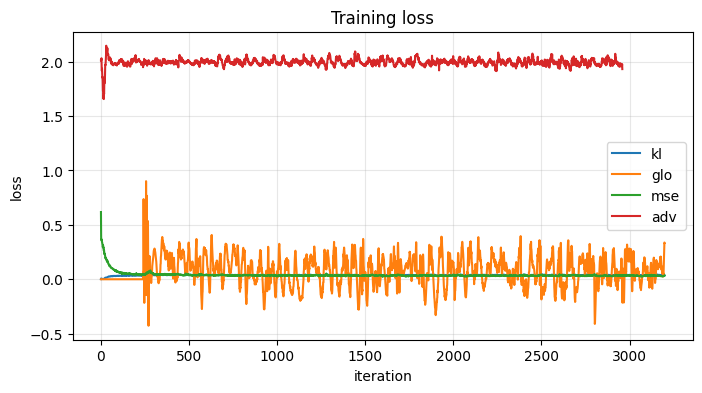

In [59]:
plt.figure(figsize=(8, 4))
plt.plot(kl, label="kl")
plt.plot(glo2, label="glo")
plt.plot(mse, label="mse")
plt.plot(adv, label="adv")
plt.xlabel("iteration")
plt.ylabel("loss")  
plt.title("Training loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Even with a bit of single GD on beta, it's hard to get 0 mean data with unit variance. That's why the paper normalize the data.

In [60]:


var = []
for _ in range(100):
    with torch.no_grad():
        X_batch, _ = next(iter(tiny_loader))
        X_batch = X_batch.to(device)
        X_batch = F.pad(X_batch, (2, 2, 2, 2))
        z = encoder(X_batch)
        mu, log_var = z.chunk(2, dim=1)

        mu_m, var_m = mu.mean().item(), torch.exp(log_var).mean().item()
        # print(var_m)
        var.append(var_m)
print(np.array(var).mean())



0.6767127925157547


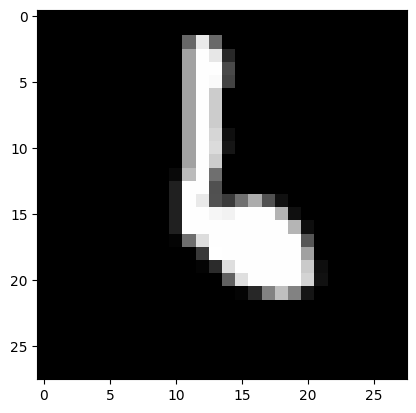

In [16]:
x0, y0 = train_set[5600]   # x.shape = 1,28,28
plt.imshow(x0[0,:,:], cmap='grey')

torch.Size([1, 4, 8, 8])


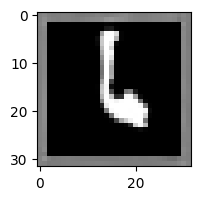

In [61]:
x0, y0 = train_set[5600]
def mar(x0):   
    x0 = F.pad(x0, (2, 2, 2, 2))
    z = encoder(x0[None, :, :, :].to(device))
    print(z.shape)   # envoyer sur device
    mu, log_var = z.chunk(2, dim=1)             # getting things
    z0 = decoder(mu + torch.randn_like(mu) * torch.exp(log_var * 0.5))
    return z0[0,0,:,:].detach().cpu()
plt.figure(figsize=(2, 2))  
plt.imshow(mar(x0), cmap='gray')



## Torch.compile
The compiler needs to recompile a new graph cause we don't have the same input shape in the batch, that's why plotting only 1 image after the training takes 30 secondes and it's instant after that.

# Lets begin diffusing

cosine schedule

In [62]:
import math
def cosine_beta(ts,s=0.008):
    """
    cosine beta schedule
    """
    steps = torch.arange(ts+1,dtype=torch.float32) #float32 (not 16) is important here for the beginning of the training
    f_t = torch.cos( (math.pi/2)*(steps/ts + s)/(1+s))**2
    print(f_t.dtype)
    alphas = f_t/f_t[0]
    return torch.clip(1 - alphas[1:]/alphas[:-1], 0 , 0.999)

 Diffusion model

In [63]:
class GaussianDiffusion(nn.Module):
    def __init__(self, model, timesteps=300, beta_start=3.3e-4, beta_end=0.07):
        super().__init__()
        self.model = model
        self.timesteps = timesteps
        self.beta_start = beta_start
        self.beta_end = beta_end

        # betas = torch.linspace(beta_start, beta_end, timesteps)
        betas = cosine_beta(timesteps)
        alphas = 1. - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)
        alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.)

        self.register_buffer("betas",betas)
        self.register_buffer("alphas", alphas)
        self.register_buffer("alphas_cumprod", alphas_cumprod)
        self.register_buffer("alphas_cumprod_prev", alphas_cumprod_prev)
        self.register_buffer("sqrt_alphas_cumprod",  torch.sqrt(alphas_cumprod))
        self.register_buffer("sqrt_one_minus_alphas_cumprod",torch.sqrt(1. - alphas_cumprod))

    
    
    def q_sampling(self, x0, t, noise):
        """ 
        Computing q(x_t | x0) for batch=b
        Cautious with dimensions!:
        x0 : b x C x H x W
        noise : x0 like 
        t : b
        """
        sqrt_alpha_t           = self.sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)           # (B, 1, 1, 1)
        sqrt_one_minus_alpha_t = self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1) # like ^

        x_t = sqrt_alpha_t * x0 + sqrt_one_minus_alpha_t * noise
        return x_t
    
    def p_loss(self, x0, context=True):
        """
        Compute the loss from x0 -> (B, *)
        """
        B, nts = x0.shape[0], self.timesteps # we need that for the time 
        t = torch.randint(nts, (B,), device=x0.device) #we take t uniform, but this isn't optimal since the solution is easy for low t or high t, but harder for middle t.
        noise = torch.randn_like(x0)
        x_t = self.q_sampling(x0, t, noise) 
        if context == True:
            noise_pred = self.model(x_t, t)       
        else: 
            noise_pred = self.model(x_t)
        loss_t = ((noise - noise_pred)**2).mean(dim=(1,2,3))
        loss = loss_t.mean()
        return loss
    
    def p_sampling(self, x, t, eps):
        """
        Computing x_t-1 from eps_theta and x_t
        """
        alpha_t = self.alphas[t].view(-1, 1, 1, 1) #being careful with broadcasting
        sqrt_one_minus_alpha_bar_t = self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1) #being careful with broadcasting
        beta_t = self.betas[t].view(-1, 1, 1, 1) #being careful with broadcasting
        z = torch.zeros_like(x) if t[0].item() == 0 else torch.randn_like(x) # that one is important (will be zero in DDIM)
        x_t_1 = 1/torch.sqrt(alpha_t) * (x - ((1 - alpha_t)/sqrt_one_minus_alpha_bar_t) * eps) + torch.sqrt(beta_t) * z
        return x_t_1
    
    def p_sampling_ddim(self, x, t, eps, s):
        """
        DDIM method of sampling
        """
        alpha_s = self.sqrt_alphas_cumprod[s].view(-1, 1, 1, 1) #being careful with broadcasting
        alpha_t = self.sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
        sqrt_one_minus_alpha_bar_t = self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1) #being careful with broadcasting
        sqrt_one_minus_alpha_bar_s = self.sqrt_one_minus_alphas_cumprod[s].view(-1, 1, 1, 1)
        # z = torch.zeros_like(x) if t[0].item() == 0 else torch.randn_like(x) # that one is important (will be zero in DDIM)
        x_s = alpha_s/alpha_t * (x - sqrt_one_minus_alpha_bar_t * eps) + sqrt_one_minus_alpha_bar_s * eps
        return x_s
        

Sinus embedding

In [64]:
import math
class Sinusembed(nn.Module):
    """
    sinusoidal embedding of time
    """
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        """
        t -> (B,)
        """
        #device = x.device # maybe if I want to train on gpu with bigger models than mnist
        N=10000 #Attention is all you need  N**(k/(dim//2)) 
        h_dim = self.dim//2
        emb = math.log(N)/(h_dim)
        emb = torch.exp(torch.arange(h_dim) * -emb).to(device) # (h_dim,)  # I have to know when to put device or not
        emb = t[:, None] * emb[None,:] #careful with broadcast
        return torch.cat((emb.sin(), emb.cos()), dim=-1)




In [65]:
class RMSnorm(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.scale = dim**0.5
        self.g = nn.Parameter(torch.ones(1, dim, 1, 1))
    def forward(self,x):
        return F.normalize(x, dim=1) * self.g * self.scale #Pytorch formula normalize is the L2 and then we have the



class Resblock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()

        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        # self.norm1 = nn.GroupNorm(8, out_ch) #batch norm
        self.norm1 = RMSnorm(out_ch) #we use RMSnorm which is more efficient
        self.act1 = nn.SiLU()
        
        self.time_proj = nn.Sequential(nn.SiLU(),nn.Linear(time_dim, 2 * out_ch)) # we're doing that for the scale and shift instead of just adding the time
        # self.time_proj = nn.Linear(time_dim, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        # self.norm2 = nn.GroupNorm(8, out_ch) #batch norm
        self.norm2 = RMSnorm(out_ch)
        self.act2 = nn.SiLU()
        #res_conv = conv1x1 will be useful in upsampling
        self.res_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity() #we need output and skip(x) to have the same dim
        # self.dropout = nn.Dropout(0.1) # let's see what it does
    def forward(self, x, t_emb=None):
        #block 1
        if t_emb is not None:
            t_context = self.time_proj(t_emb) #(B, 2 * out_ch)
            t_context = t_context[:,:,None,None] # We need the time_context to match output (B, 2 * out_ch, 1, 1)
            scale, shift = t_context.chunk(2, dim=1) #tuple (B, out_ch,1,1)
        
        h1 = self.conv1(x)
        h1 = self.norm1(h1)
        if t_emb is not None:
            h1 = h1 * (1 + scale) + shift #scale shift DONT FORGET TO TRY WHITHOUT SCALE adaGN
        h1 = self.act1(h1)
        #block 2
        # h1 = self.dropout(h1)
        h2 = self.conv2(h1)
        h2 = self.norm2(h2)
        h2 = self.act2(h2)
        return (h2 + self.res_conv(x)) /np.sqrt(2) #adding variance normalisation with 1/sqrt(2)  



Unet & company

In [66]:
def Downsample(dima, dimb):
    return nn.Conv2d(dima, dimb, kernel_size=2, stride=2) # we divide by 2 the image feature resolution
def Upsample(dima, dimb):
    return nn.Sequential(
        nn.Upsample(scale_factor=2, mode="bilinear"), #got helped by google on that one
        nn.Conv2d(dima, dimb, 3, padding=1),
    )
    

class Unet(nn.Module):
    def __init__(self,
                dim,# start dim of embedding in the Unet
                dim_mults=(2, 4),  # lets see
                channel=1  # input channel of our images, mnist is 1
    ):
        super().__init__()
        self.dim = dim
        self.channel = channel
        self.init_conv = nn.Conv2d(channel, dim, kernel_size=3, padding=1) #we keep the same image_size kernel=3 padd=1
        
        #getting the dimensions for ups and downs
        dims = [dim] + [dim * m for m in dim_mults]
        in_out = list(zip(dims[:-1], dims[1:])) #giving couple of (in_ch, out_ch)
        
        #timesteps encoder
        time_dim = dim*4 # we make the time embeddign big enough to be approx equal to feature embedding
        self.t_embed = nn.Sequential(Sinusembed(self.dim), nn.Linear(dim, time_dim), nn.GELU(), nn.Linear(time_dim, time_dim))
        #ResBlocks downs
        self.downs = nn.ModuleList([])
        for (in_ch, out_ch) in in_out:
            down = nn.ModuleList([Resblock(in_ch, in_ch, time_dim), Resblock(in_ch, in_ch, time_dim), Downsample(in_ch, out_ch)])
            self.downs.append(down)
        
        #Midblocks
        mid_dim = dims[-1]
        self.mid_block1 = Resblock(mid_dim, mid_dim, time_dim)
        self.mid_block2 = Resblock(mid_dim, mid_dim, time_dim)

        # Resblock up
        self.ups = nn.ModuleList([])
        for (out_ch, in_ch) in reversed(in_out): #careful with the order in_ch, out_ch
            #we multiply by 2, cause we add the vector of the downresblocks as context
            up = nn.ModuleList([Upsample(in_ch, out_ch ),Resblock(2 * out_ch, out_ch, time_dim), Resblock(2 * out_ch, out_ch, time_dim)]) 
            self.ups.append(up)
        
        self.final_conv = nn.Conv2d(dim, channel, 1) #back to channel of the input

    def forward(self, x, t=None):
        if t is not None:
            t_emb = self.t_embed(t)
        else:
            t_emb=None
        x = self.init_conv(x)
        
        skips = []
        for down in self.downs:
            res1, res2, dsample = down
            x = res1(x, t_emb)
            skips.append(x)
            x = res2(x, t_emb)
            skips.append(x)
            x = dsample(x)
        x = self.mid_block1(x, t_emb)
        x = self.mid_block2(x, t_emb)
        for up in self.ups:
            upsample, res1, res2 = up
            x = upsample(x)
            x = torch.cat((x, skips.pop()), dim=1)
            x = res1(x, t_emb)
            x = torch.cat((x, skips.pop()), dim=1)
            x = res2(x, t_emb)
        x = self.final_conv(x)
        return x


        


training

1st test: encoder: [1,2], need padding, Unet [16, 2] Unet_dim = 4

In [67]:
ts=300

torch.float32


/tmp/ipykernel_1183/2304073699.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


epoch 0: loss = 0.640783


/tmp/ipykernel_1183/2304073699.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


epoch 100: loss = 0.480445
epoch 200: loss = 0.498137
epoch 300: loss = 0.521913
epoch 400: loss = 0.508874


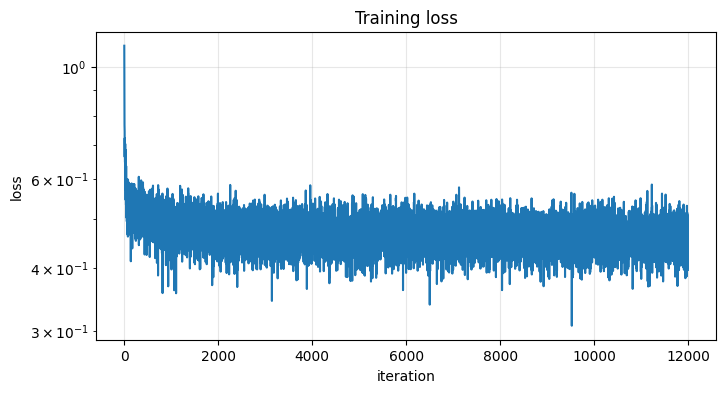

In [68]:
v_m = 0.6767127925157547
model = torch.compile(Unet(32, [1], 2)).to(device) #before after? speeding

from torch.utils.data import Subset, DataLoader
# try +2000 to start getting results with DDIM
tiny_set = Subset(train_set, range(3000)) #using the whole dataset is too long to train
tiny_loader = DataLoader(tiny_set, batch_size=128, shuffle=True)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
diff = GaussianDiffusion(model, timesteps=ts).to(device)
losses = []
def train_loops(dataloader, diffusion, optimizer):
    diffusion.train()
    scaler = torch.cuda.amp.GradScaler() 
    for _, (X, _) in enumerate(dataloader):
        X = X.to(device)
        with torch.no_grad():
            X = F.pad(X, (2, 2, 2, 2))
            X = encoder(X)/v_m
            mu, log_var = X.chunk(2, dim=1)
            eps = torch.randn_like(mu, device=mu.device)
            X = mu + eps * torch.exp(0.5 * log_var)
            # X = F.pad(X, (0, 1, 0, 1)) # for the moment my encoder give 7x7 images???
        with torch.autocast("cuda"):
            
            loss= diffusion.p_loss(X, context=True)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()
        losses.append(loss.item())


epochs = 500 
for epoch in range(epochs):
    train_loops(tiny_loader, diff, optimizer)
    if epoch % 100 == 0:
        print(f"epoch {epoch}: loss = {losses[-1]:.6f}")
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel("iteration")
plt.ylabel("loss")
plt.yscale("log")
plt.title("Training loss")
plt.grid(True, alpha=0.3)
plt.show()

### Loss

Looking at the loss, the model seems not to learn anything, that's because it put almost the same numbers of epoch although now we're working with 2x8x8 latent images instead of 1x28x28. The model doesn't need that much of epoch to learn.

I put some padding, so that I can downsampling correctly

The 1st training loss looks like nothing good

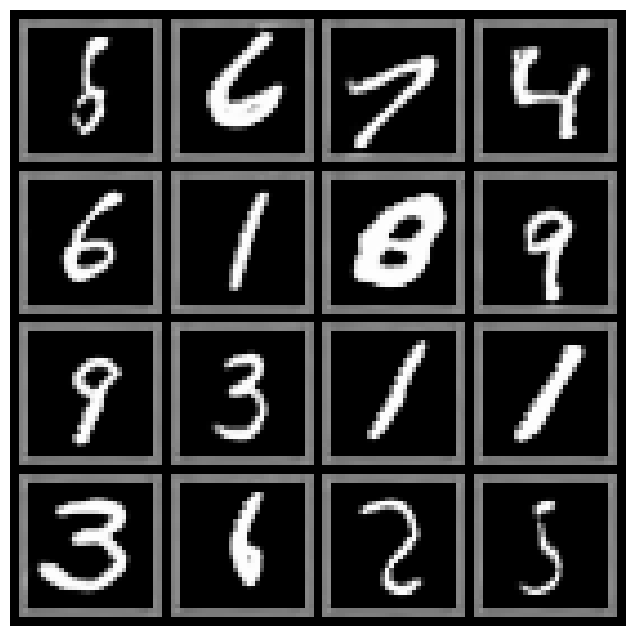

In [71]:
import torchvision.utils as vutils

n_samples = 16

x_f = torch.randn(n_samples, 2, 8, 8, device=device)
model.eval()
with torch.no_grad():
    for t in range( 299, -1, -1):
        t_batch = torch.full((n_samples,), t, dtype=torch.long).to(device) 
        eps = model(x_f, t_batch)
        x_f = diff.p_sampling(x_f, t_batch, eps)
    x_f = decoder(x_f)
samples = ((x_f + 1) / 2).clamp(0, 1)

grid = vutils.make_grid(samples.detach().cpu(), nrow=4) #made by claude
plt.figure(figsize=(8, 8))                              #made by claude
plt.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')  # that too
plt.axis('off')
plt.show()

## 1st try 
The first experiment gives strange numbers.  
The Encoder-Decoder seems to give back the image, but did he really learn a good representation of the data. That may be one cause.
2nd try:
Look a lot better and we gain a lot of time during the sampling??? 

## Crazy
Actually it Works, really crazy!!!
